In [3]:
from src.env import RenderConfig, precalculate_render, render_obs, GridWorld
print("import ok")

import ok


In [4]:
from src.env import RenderConfig, precalculate_render, render_obs

cfg = RenderConfig()
cache = precalculate_render(cfg)

img = render_obs(agent_pos=(1, 1), target_pos=(3, 2), cache=cache)
print(img.shape, img.dtype, img.min(), img.max())

(128, 128) uint8 17 255


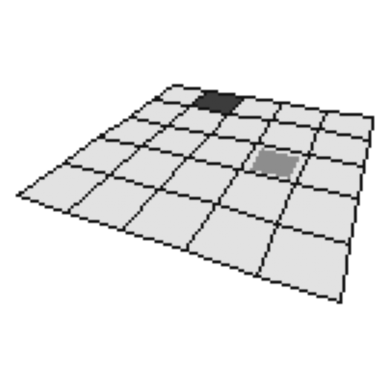

In [11]:
import matplotlib.pyplot as plt
from src.env import RenderConfig, precalculate_render, render_obs

cfg = RenderConfig()
cache = precalculate_render(cfg)

img = render_obs(agent_pos=(1, 2), target_pos=(3, 4), cache=cache)

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

In [15]:
from src.env import GridWorld

env = GridWorld(N=5)
agent, target = env.reset()
print("reset :", agent, target)


for action in [0, 0, 3, 3, 1]:
    agent, target, done = env.step(action)
    print("step :", agent, target, done)

reset : (4, 0) (4, 1)
step : (4, 1) (4, 1) True
step : (4, 2) (4, 1) False
step : (4, 2) (4, 1) False
step : (4, 2) (4, 1) False
step : (4, 1) (4, 1) True


# test_colab.ipynb

Mini notebook de validation du workflow `local → GitHub → Google Colab`.

Ce notebook sert à vérifier que :

- le notebook s'ouvre et s'exécute en local
- Google Colab est détecté correctement
- Google Drive peut être monté
- un mini dataset dummy est créé
- un dummy model PyTorch s'entraîne quelques itérations
- le dataset et le modèle sont bien sauvegardés dans  
  `Mon Drive/projetColab/wm_colab/test_run`

Il est volontairement simple, lisible et pédagogique.

## 1. Détection de l'environnement et chemins

En local, rien n'est monté automatiquement.  
Dans Colab, le notebook monte Google Drive et écrit dans :

`Mon Drive/projetColab/wm_colab/test_run`

In [1]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    BASE_DIR = Path("/content/drive/MyDrive/projetColab/wm_colab/test_run")
else:
    # Fallback local pour pouvoir tester le notebook sans Colab
    BASE_DIR = Path("./local_test_run")

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
LOG_DIR = BASE_DIR / "logs"

for d in [BASE_DIR, DATA_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"IN_COLAB = {IN_COLAB}")
print(f"BASE_DIR = {BASE_DIR.resolve() if not IN_COLAB else BASE_DIR}")
print("Dossiers prêts :")
print(f"  - {DATA_DIR}")
print(f"  - {MODEL_DIR}")
print(f"  - {LOG_DIR}")

IN_COLAB = False
BASE_DIR = /home/alexandre/Documents/projetsCode/WModel/wm_colab/local_test_run
Dossiers prêts :
  - local_test_run/data
  - local_test_run/models
  - local_test_run/logs


## 2. Imports et seed

On importe les libs dont on aura besoin plus tard dans le vrai projet :

- `numpy`
- `torch`
- `matplotlib`
- `pathlib`

In [2]:
import json
import math
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch version :", torch.__version__)
print("Device        :", DEVICE)
if DEVICE == "cuda":
    print("GPU           :", torch.cuda.get_device_name(0))

Torch version : 2.11.0+cu130
Device        : cpu


/home/alexandre/anaconda3/envs/wm_colab/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 3. Création d'un mini dataset dummy

Ici on génère un faux dataset de régression :

- `x` : 2 features
- `y` : combinaison linéaire bruitée

On sauvegarde ensuite le dataset sur disque.

In [3]:
N = 256

x = np.random.randn(N, 2).astype(np.float32)
noise = 0.15 * np.random.randn(N).astype(np.float32)
y = (2.0 * x[:, 0] - 3.0 * x[:, 1] + 0.5 + noise).astype(np.float32)

dataset_path = DATA_DIR / "dummy_dataset.npz"
np.savez_compressed(dataset_path, x=x, y=y)

print(f"Dataset sauvegardé : {dataset_path}")
print("Shapes :")
print("  x :", x.shape, x.dtype)
print("  y :", y.shape, y.dtype)

Dataset sauvegardé : local_test_run/data/dummy_dataset.npz
Shapes :
  x : (256, 2) float32
  y : (256,) float32


## 4. Vérification : rechargement du dataset depuis le disque

On relit ce qu'on vient d'écrire pour simuler un vrai notebook d'entraînement.

In [4]:
loaded = np.load(dataset_path)
x_loaded = loaded["x"]
y_loaded = loaded["y"]

print("Dataset relu depuis disque :")
print("  x_loaded :", x_loaded.shape, x_loaded.dtype)
print("  y_loaded :", y_loaded.shape, y_loaded.dtype)
print("Premier exemple :")
print("  x =", x_loaded[0], " | y =", y_loaded[0])

Dataset relu depuis disque :
  x_loaded : (256, 2) float32
  y_loaded : (256,) float32
Premier exemple :
  x = [ 0.49671414 -0.1382643 ]  | y = 1.8723791


## 5. Visualisation rapide

Une figure simple pour vérifier que matplotlib fonctionne bien localement et dans Colab.

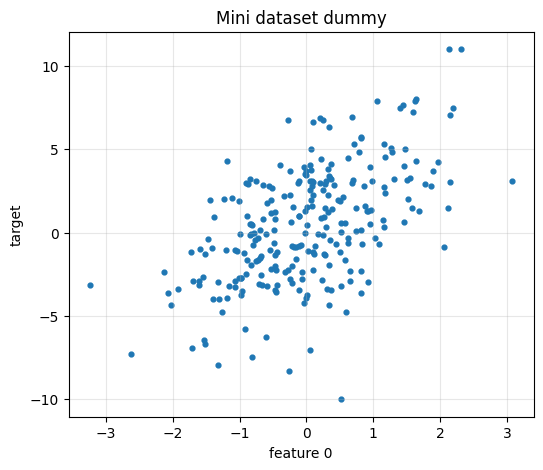

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(x_loaded[:, 0], y_loaded, s=12)
plt.xlabel("feature 0")
plt.ylabel("target")
plt.title("Mini dataset dummy")
plt.grid(True, alpha=0.3)
plt.show()

## 6. DataLoader PyTorch

On convertit le dataset en tenseurs et on prépare un DataLoader.

In [6]:
X_tensor = torch.tensor(x_loaded, dtype=torch.float32)
y_tensor = torch.tensor(y_loaded, dtype=torch.float32).unsqueeze(1)

ds = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(ds, batch_size=32, shuffle=True)

xb, yb = next(iter(loader))
print("Mini-batch shapes :")
print("  xb :", xb.shape)
print("  yb :", yb.shape)

Mini-batch shapes :
  xb : torch.Size([32, 2])
  yb : torch.Size([32, 1])


## 7. Dummy model

Un petit MLP très simple juste pour tester :

- forward
- backward
- optimizer
- entraînement sur CPU ou GPU

In [7]:
class DummyRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.net(x)

model = DummyRegressor().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

print(model)

DummyRegressor(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)


## 8. Mini entraînement

Quelques epochs seulement, juste pour vérifier que tout fonctionne.

In [8]:
n_epochs = 20
history = []

t0 = time.time()

for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    mean_loss = running_loss / len(loader)
    history.append(mean_loss)

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | loss = {mean_loss:.6f}")

elapsed = time.time() - t0
print(f"Training terminé en {elapsed:.2f}s")

Epoch 01 | loss = 11.425226
Epoch 05 | loss = 0.755793
Epoch 10 | loss = 0.114337
Epoch 15 | loss = 0.046952
Epoch 20 | loss = 0.034301
Training terminé en 0.12s


## 9. Courbe de loss

Encore une vérification visuelle simple.

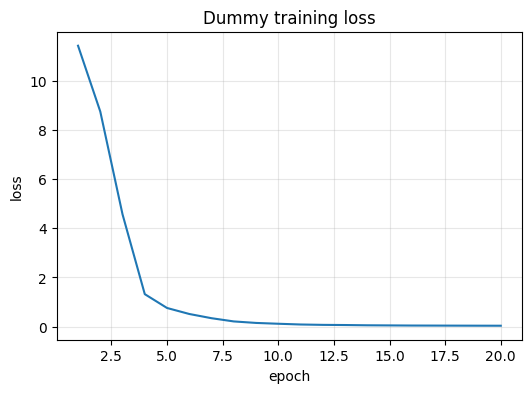

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, n_epochs + 1), history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Dummy training loss")
plt.grid(True, alpha=0.3)
plt.show()

## 10. Sauvegarde du modèle sur disque

On enregistre :

- les poids
- quelques métadonnées

In [10]:
model_path = MODEL_DIR / "dummy_model.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "device": DEVICE,
        "n_epochs": n_epochs,
        "final_loss": history[-1],
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    },
    model_path,
)

print(f"Modèle sauvegardé : {model_path}")

Modèle sauvegardé : local_test_run/models/dummy_model.pt


## 11. Test de rechargement du modèle

On vérifie qu'un `torch.load` fonctionne bien.

In [11]:
checkpoint = torch.load(model_path, map_location="cpu")
print("Clés du checkpoint :")
print(list(checkpoint.keys()))
print("Final loss :", checkpoint["final_loss"])

Clés du checkpoint :
['model_state_dict', 'device', 'n_epochs', 'final_loss', 'timestamp']
Final loss : 0.03430058085359633


## 12. Petit fichier de log JSON

On crée aussi un log texte/JSON pour vérifier les écritures annexes.

In [12]:
run_info = {
    "in_colab": IN_COLAB,
    "base_dir": str(BASE_DIR),
    "dataset_path": str(dataset_path),
    "model_path": str(model_path),
    "device": DEVICE,
    "n_samples": int(N),
    "n_epochs": int(n_epochs),
    "final_loss": float(history[-1]),
}

log_path = LOG_DIR / "run_info.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(run_info, f, indent=2, ensure_ascii=False)

print(f"Log sauvegardé : {log_path}")

Log sauvegardé : local_test_run/logs/run_info.json


## 13. Résumé final

Si tout s'est bien passé, tu dois avoir :

- un dataset `.npz`
- un modèle `.pt`
- un log `.json`

Dans Colab :
`Mon Drive/projetColab/wm_colab/test_run`

En local :
`./local_test_run`

In [13]:
print("Résumé des fichiers créés :")
for path in [dataset_path, model_path, log_path]:
    print(f"  - {path} | existe = {path.exists()} | taille = {path.stat().st_size} octets")

Résumé des fichiers créés :
  - local_test_run/data/dummy_dataset.npz | existe = True | taille = 3326 octets
  - local_test_run/models/dummy_model.pt | existe = True | taille = 4613 octets
  - local_test_run/logs/run_info.json | existe = True | taille = 264 octets
